In [3]:
import pandas as pd
df = pd.read_csv(
    "../dataset/severity_dataset.csv"
)

In [4]:
def congestion_score(row):

    score = 10

    if row["priority"] == "High":
        score += 20

    if row["requires_road_closure"]:
        score += 30

    if row["event_type"] == "unplanned":
        score += 15

    if row["event_cause"] in [
        "accident",
        "construction",
        "water_logging",
        "public_event",
        "procession"
    ]:
        score += 15

    if row["hour"] in [
        5,
        6,
        19,
        20,
        21
    ]:
        score += 10

    return min(score,100)

In [5]:
df["congestion_score"] = df.apply(
    congestion_score,
    axis=1
)

In [6]:
df["congestion_score"].describe()

count    8173.000000
mean       45.781843
std        13.694646
min        10.000000
25%        35.000000
50%        45.000000
75%        55.000000
max       100.000000
Name: congestion_score, dtype: float64

<Axes: xlabel='congestion_score', ylabel='Count'>

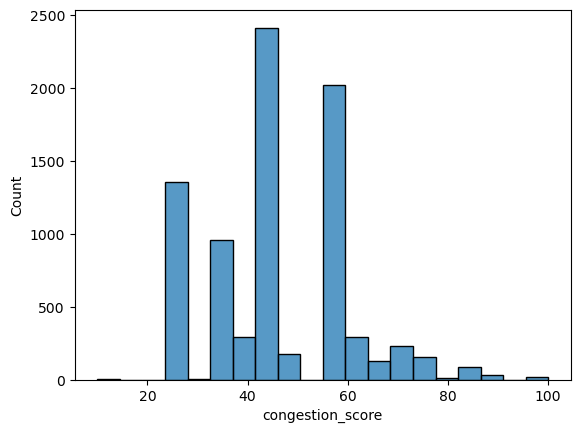

In [7]:
import seaborn as sns

sns.histplot(
    df["congestion_score"],
    bins=20
)

In [8]:
features = [

    "event_type",
    "event_cause",
    "priority",
    "requires_road_closure",
    "zone",
    "police_station",
    "latitude",
    "longitude",
    "hour",
    "day"
]

In [9]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in [
    "event_type",
    "event_cause",
    "priority",
    "zone",
    "police_station"
]:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    encoders[col] = le

In [17]:
day_map = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6
}

df["day"] = df["day"].map(day_map)

In [18]:
print(df["day"].dtype)
print(df["day"].head())

int64
0    3
1    1
2    5
3    3
4    1
Name: day, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

X = df[features]

y = df["congestion_score"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05
)

model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
print(df["day"].dtype)
print(X["day"].dtype)
print(X.head())

object
object
   event_type  event_cause  priority  requires_road_closure  zone  \
0           1           14         0                  False    10   
1           1           14         0                  False    10   
2           1            6         1                  False     1   
3           1           13         1                   True    10   
4           1           14         1                  False    10   

   police_station   latitude  longitude  hour       day  
0              39  13.040004  77.518099    17  Thursday  
1              15  12.921876  77.645158     4   Tuesday  
2              51  12.955622  77.585708     6  Saturday  
3              43  13.006147  77.579435    17  Thursday  
4              51  12.953980  77.585233     4   Tuesday  


In [15]:
print(X.dtypes)
print(X.select_dtypes(include=["object"]).columns.tolist())

event_type                 int64
event_cause                int64
priority                   int64
requires_road_closure       bool
zone                       int64
police_station             int64
latitude                 float64
longitude                float64
hour                       int64
day                       object
dtype: object
['day']


In [11]:
print(X.select_dtypes(include=["object"]).columns.tolist())

['day']


In [20]:
from sklearn.metrics import r2_score

pred = model.predict(X_test)

print(
    "R2 Score:",
    r2_score(y_test,pred)
)

R2 Score: 0.9958397746086121


In [21]:
import joblib

joblib.dump(
    model,
    "../models/congestion_model.pkl"
)

['../models/congestion_model.pkl']